# 05 · Time series — ATL13 pass water levels

ICESat-2 pass WSE (EVRS) over time, split on the 2023-06-06 dam breach.
Gauge overlay is Phase 2.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from kakhovka_altimetry.config import load_config
from kakhovka_altimetry.io import read_parquet
cfg = load_config()


In [2]:
passes = read_parquet(cfg.pass_levels_parquet)
ok = passes[passes['qc_pass']].copy()
ok['datetime'] = pd.to_datetime(ok['datetime'])
breach = pd.Timestamp(cfg.regimes.breach_start)
colors = {'PRE_BREACH':'tab:blue','BREACH_DRAWDOWN':'tab:orange','POST_BREACH':'tab:red'}

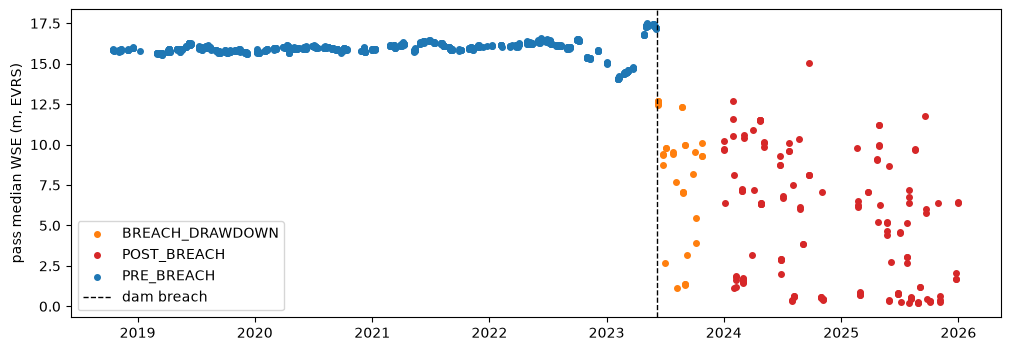

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
for period, g in ok.groupby('period'):
    ax.scatter(g['datetime'], g['median_wse_evrs_m'], s=16, label=period, color=colors.get(period))
ax.axvline(breach, color='k', ls='--', lw=1, label='dam breach')
ax.set_ylabel('pass median WSE (m, EVRS)'); ax.legend()
fig.savefig(cfg.repo_root/'outputs'/'figures'/'atl13_wse_timeseries.png', dpi=150, bbox_inches='tight')

### PRE_BREACH reservoir level by year (kept separate from post-breach)

In [4]:
pre = ok[ok['period'] == 'PRE_BREACH']
pre.groupby('year')['median_wse_evrs_m'].agg(['count','median','mean','std','min','max']).round(3)

,count,median,mean,std,min,max
year,,,,,,
2018,37,15.849,15.856,0.065,15.728,16.005
2019,227,15.817,15.849,0.172,15.551,16.278
2020,229,15.946,15.932,0.107,15.641,16.141
2021,181,16.117,16.097,0.181,15.744,16.475
2022,184,16.196,16.162,0.292,15.306,16.579
2023,99,15.042,15.807,1.418,14.047,17.492


In [5]:
ok[ok['period'] != 'PRE_BREACH'].groupby('period')['median_wse_evrs_m'].agg(['count','median','min','max']).round(3)

,count,median,min,max
period,,,,
BREACH_DRAWDOWN,34,9.376,1.140,12.697
POST_BREACH,147,5.198,0.182,15.039
